# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [9]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [11]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [12]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [13]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [14]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [15]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [16]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [17]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [18]:
# cantidad de nulos para users
print (users.isna().sum()) # Cantidad de valores nulos
print (users.isna().mean()) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [19]:
# cantidad de nulos para usage
print (usage.isna().sum())
print (usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64



El análisis del dataset Users muestra que la columna city tiene 469 valores nulos, lo que representa solo el 0.12% de los registros. Debido a que es una proporción muy pequeña, recomiendo mantener estos registros y reemplazar los valores nulos por "Unknown" (desconocido), en lugar de eliminar las filas. Por otro lado, la columna churn_date presenta 3,534 valores nulos, equivalentes al 88.35% de los registros. En este caso, los valores nulos probablemente indican que los usuarios no han abandonado el servicio, por lo que recomiendo mantenerlos como valores nulos y no reemplazarlos con una fecha estimada. No es recomendable eliminar los registros con valores nulos en churn_date, ya que representan una parte importante de los datos y pueden ser fundamentales para analizar el comportamiento de los usuarios y la tasa de abandono (churn).

Por otro lado, el analisis para el dataset Usage, los resultados muestran valores nulos en tres columnas: date, duration y length. Date tiene 50 valores nulos, que representan solo el 0.125% de los registros. Es una proporción muy pequeña, por lo que se podría considerar eliminar estos registros si la fecha es necesaria para el análisis temporal. Duration tiene 22,076 valores nulos, equivalentes al 55.19% de los registros. Es un porcentaje bastante alto, por lo que no sería recomendable eliminar todas estas filas. Se debe investigar primero por qué faltan estos datos y si existe una relación entre los valores nulos y el tipo de llamada. Length tiene 17,896 valores nulos, que representan el 44.74% de los registros. Al igual que duration, es una proporción considerable y eliminar estos registros podría provocar una pérdida importante de información.

Se recomienda eliminar o excluir los registros con valores nulos en date, debido a que representan únicamente el 0.125% de los datos y la fecha es necesaria para realizar análisis temporales. Para las columnas duration y length, no se recomienda eliminar los registros de manera automática, ya que los valores nulos representan el 55.19% y 44.74%, respectivamente. Primero se debería investigar el motivo de estos valores faltantes y analizar si están relacionados con algún tipo específico de llamada. Si los valores nulos representan llamadas que no fueron contestadas o que tuvieron una duración de cero, podrían conservarse o tratarse de acuerdo con esa lógica de negocio.

En caso de necesitar estos campos para cálculos específicos, se recomienda evaluar la posibilidad de reemplazarlos con 0 únicamente si se confirma que un valor nulo significa que no hubo duración o que no se realizó la llamada. No sería recomendable utilizar la media o mediana sin antes entender la razón de los valores faltantes.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [20]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


Las columnas id y user_id no presentan valores nulos ni valores evidentemente inválidos. La columna id contiene valores consecutivos desde 1 hasta 40,000 y funciona como identificador único de cada registro. 
La columna user_id contiene identificadores entre 10,000 y 13,999, correspondientes a los usuarios del conjunto de datos. Debido a que ambas columnas son identificadores, sus estadísticas descriptivas no tienen una interpretación numérica significativa. 
No se identificaron sentinels en estas variables.
Las columnas id y user_id no presentan valores nulos ni valores evidentemente inválidos. La columna id contiene valores consecutivos desde 1 hasta 40,000 y funciona como identificador único de cada registro. La columna user_id contiene identificadores entre 10,000 y 13,999, correspondientes a los usuarios del conjunto de datos. Debido a que ambas columnas son identificadores, sus estadísticas descriptivas no tienen una interpretación numérica significativa. No se identificaron sentinels en estas variables.

In [21]:
# explorar columnas numéricas de usage
usage [['id', 'user_id']].describe ()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


Las columnas id y user_id no presentan valores nulos ni valores evidentemente inválidos. La columna id contiene valores consecutivos desde 1 hasta 40,000 y funciona como identificador único de cada registro. La columna user_id contiene identificadores entre 10,000 y 13,999, correspondientes a los usuarios del conjunto de datos. Debido a que ambas columnas son identificadores, sus estadísticas descriptivas no tienen una interpretación numérica significativa. No se identificaron sentinels en estas variables.

In [22]:
# explorar columnas categóricas de users
users['plan'].unique()
users['plan'].value_counts(dropna=False)

users['city'].unique()
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

En la columna 'city' se identificaron diferentes ciudades, siendo Bogotá la categoría más frecuente con 808 registros. También se encontraron 469 valores nulos y 96 registros con el valor ?. El valor ? no corresponde a una ciudad válida y se considera un sentinel, probablemente utilizado para representar información desconocida. Se recomienda convertir estos valores a NaN para tratarlos de manera uniforme como datos faltantes.
La columna plan solo tiene dos categorias, basico y premium. No informacion que se considere sentinel.

In [23]:
# explorar columna categórica de usage
usage['type'] .unique
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

La columna type contiene dos categorías: text y call. La categoría text representa 22,092 registros (55.23%), mientras que call representa 17,908 registros (44.77%). No se identificaron valores nulos ni valores que puedan considerarse sentinels. Por lo tanto, la variable presenta categorías válidas y consistentes para el análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [24]:
# Convertir a fecha la columna `reg_date` de users

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

print(users['reg_date'].dtype)

# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

print('Fechas no válidas:', users['reg_date'].isna().sum())

print('Fecha mínima:', users['reg_date'].min())
print('Fecha máxima:', users['reg_date'].max())


datetime64[ns]
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64
Fechas no válidas: 0
Fecha mínima: 2022-01-01 00:00:00
Fecha máxima: 2026-05-10 00:00:00


La columna reg_date fue convertida correctamente al formato datetime64[ns] y no se encontraron errores de conversión. Las fechas válidas del conjunto de datos corresponden al período comprendido entre el 1 de enero de 2022 y el 31 de diciembre de 2024. Sin embargo, se identificaron 40 registros con fechas de 2026, las cuales son inconsistentes con el período de estudio y, por lo tanto, se consideran fechas imposibles. Estos registros deben ser revisados y corregidos o excluidos antes de realizar el análisis temporal.

In [25]:
# Convertir a fecha la columna `date` de usage

usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

print(usage['date'].dtype)

# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

print('Fechas no válidas:', usage['date'].isna().sum())

print('Fecha mínima:', usage['date'].min())
print('Fecha máxima:', usage['date'].max())

datetime64[ns]
2024.0    39950
Name: date, dtype: int64
Fechas no válidas: 50
Fecha mínima: 2024-01-01 00:00:00
Fecha máxima: 2024-06-30 00:00:00


La columna date fue convertida correctamente al formato datetime64[ns]. Los registros válidos corresponden al año 2024, con fechas comprendidas entre el 1 de enero y el 30 de junio de 2024. Se identificaron 50 fechas no válidas, que representan aproximadamente el 0.125% de los registros. Estos valores deben ser revisados, ya que pueden corresponder a datos faltantes o fechas ingresadas incorrectamente. Debido a que representan una proporción muy pequeña del dataset, podrían excluirse del análisis temporal si no es posible recuperar las fechas originales.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [26]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [27]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users ['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [28]:
# Marcar fechas futuras como NA para reg_date
users.loc[
    (users['reg_date'].dt.year < 2022) |
    (users['reg_date'].dt.year > 2024),
    'reg_date'
] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [29]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean() * 100)

type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [30]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean() * 100)

type
call    99.932991
text     0.000000
Name: length, dtype: float64

Se analizó la proporción de valores nulos en duration y length según la variable type. Se observa que la presencia de valores faltantes está relacionada con el tipo de registro. Esto sugiere que los valores nulos no son aleatorios y pueden considerarse MAR (Missing At Random). Por esta razón, se decidió mantener los valores nulos, ya que reemplazarlos mediante imputación podría introducir información incorrecta y distorsionar el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 

1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas


2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [31]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    numero_total_de_mensajes=('type', lambda x: (x == 'text').sum()),
    numero_total_de_llamadas=('type', lambda x: (x == 'call').sum()),
    total_de_minutos_de_llamadas=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)



,user_id,numero_total_de_mensajes,numero_total_de_llamadas,total_de_minutos_de_llamadas
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [42]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'numero_total_de_mensajes': 'cant_mensajes',
    'numero_total_de_llamadas': 'cant_llamadas',
    'total_de_minutos_de_llamadas':'cant_minutos_llamada'})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [33]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on='user_id',
    how='left'
)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [34]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [35]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

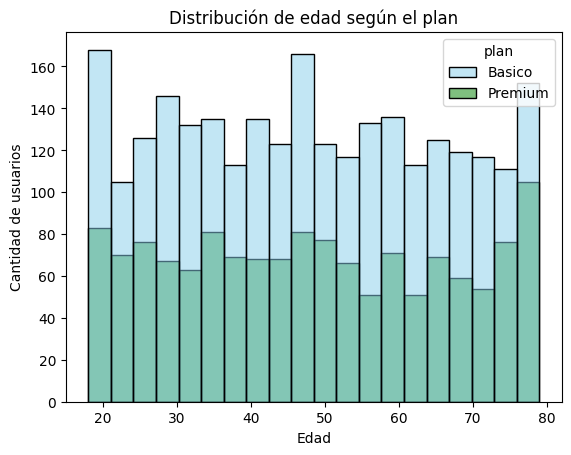

In [36]:
# Histograma para visualizar la edad (age)

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)
plt.title('Distribución de edad según el plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:La distribución de edades es bastante similar entre los planes Básico y Premium. Ambos planes presentan usuarios distribuidos a lo largo de un rango amplio de edades, aproximadamente entre 18 y 79 años. No se observa una concentración claramente mayor de un plan en un rango específico de edad.

La distribución parece relativamente uniforme, aunque presenta algunas variaciones entre los diferentes rangos de edad. Por lo tanto, no se identifica un patrón fuerte que relacione la edad de los usuarios con el tipo de plan.

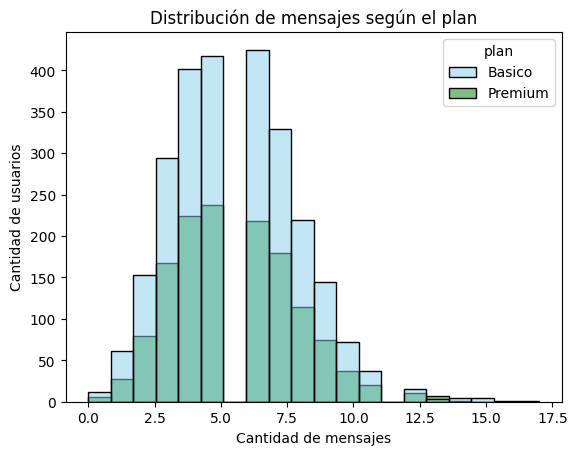

In [37]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de mensajes según el plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: Los usuarios de ambos planes presentan una concentración principalmente entre 3 y 8 mensajes, pero la distribución del plan Básico muestra una mayor cantidad de usuarios en estos rangos. Ambos grupos presentan un sesgo hacia la derecha, ya que la mayoría de los usuarios envía una cantidad relativamente baja de mensajes, mientras que existe un grupo pequeño que envía cantidades considerablemente mayores, llegando hasta aproximadamente 17 mensajes.

En general, no se observa una diferencia muy marcada en el comportamiento de envío de mensajes entre los dos planes, aunque el plan Básico concentra un mayor número de usuarios en los rangos más frecuentes.

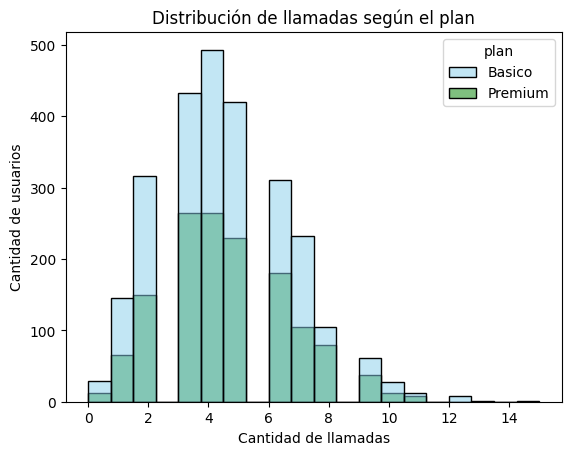

In [38]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de llamadas según el plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: La distribución de llamadas permite comparar el comportamiento de los usuarios según el plan. Si las distribuciones se superponen considerablemente, no existe una diferencia clara en la cantidad de llamadas realizadas entre ambos planes. La distribución presenta un sesgo hacia la derecha, con algunos usuarios que realizan un número elevado de llamadas.

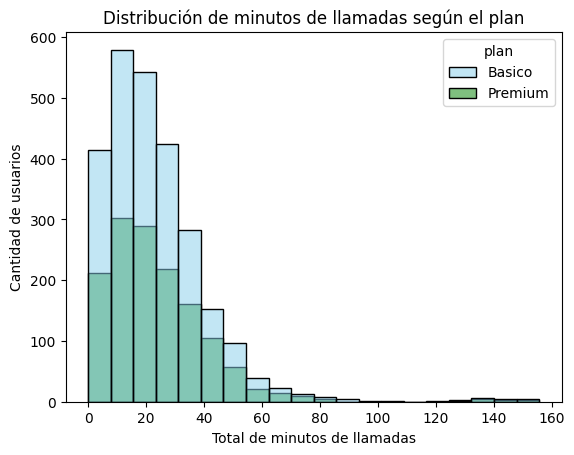

In [39]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de minutos de llamadas según el plan')
plt.xlabel('Total de minutos de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
Los usuarios del plan Premium tienden a concentrar un mayor número de minutos de llamadas en comparación con los usuarios del plan Básico. La distribución presenta un sesgo hacia la derecha, ya que la mayoría de los usuarios tiene un consumo moderado, mientras que un grupo reducido presenta un consumo mucho mayor.

### 5.2 Identificación de Outliers



🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.



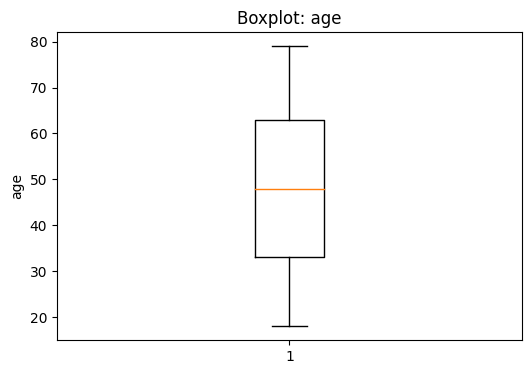

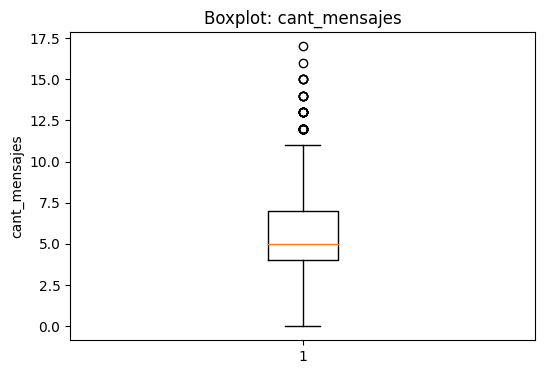

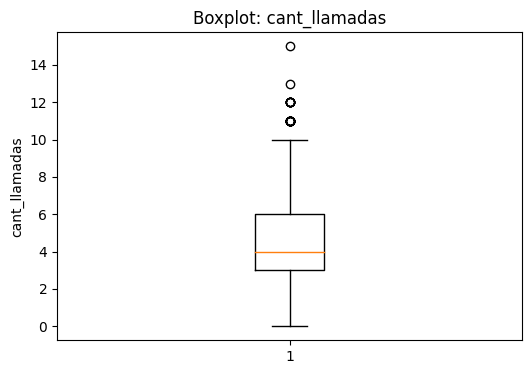

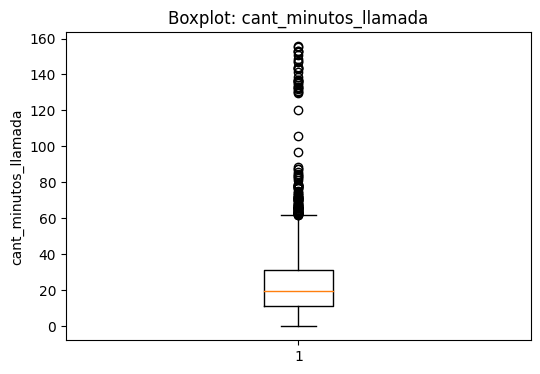

In [45]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    plt.boxplot(user_profile[col].dropna())
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()

💡Insights: 
- Age: No presenta outliers, El bigote inferior está alrededor de 18 años. El bigote superior llega aproximadamente a 79 años.
No aparecen puntos fuera de los bigotes, que son los que visualmente indicarían valores atípicos.
Por lo tanto, para age no sería necesario realizar limpieza de outliers mediante el método IQR.

- cant_mensajes: Sí, presenta outliers. Se observan varios puntos por encima del bigote superior, aproximadamente entre 12 y 17 mensajes. El bigote superior llega aproximadamente hasta 11 mensajes.
No se observan outliers inferiores.
Los valores extremos están concentrados únicamente en la parte superior de la distribución.
se recomienda calcular el límite superior mediante el método IQR y revisar esos registros antes de decidir si se eliminan.
  
- cant_llamadas: Si, presenta outliers, en el boxplot se observan varios puntos por encima del bigote superior. El 50% central de los datos se encuentra aproximadamente entre 3 y 6 llamadas. El bigote superior llega hasta aproximadamente 10 llamadas.
Los valores superiores a ese rango aparecen como valores atípicos.
No se observan outliers inferiores.
Es recomendable calcular el límite superior mediante IQR y revisar esos registros antes de decidir si eliminarlos.

- cant_minutos_llamada: Si, presenta outliers, lo que indica que existe un grupo de usuarios que registra un consumo de minutos considerablemente mayor al de la mayoría.
Es recomendable calcular el límite superior mediante IQR y revisar esos registros antes de decidir si eliminarlos. 

In [50]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for columna in columnas:
    Q1 = user_profile[columna].quantile(0.25)
    Q3 = user_profile[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = user_profile[(user_profile[columna] < limite_inferior) | 
                  (user_profile[columna] > limite_superior)]
    
    print(f'\nColumna: {columna}')
    print(f'Q1: {Q1:.2f}')
    print(f'Q3: {Q3:.2f}')
    print(f'IQR: {IQR:.2f}')
    print(f'Límite inferior: {limite_inferior:.2f}')
    print(f'Límite superior: {limite_superior:.2f}')
    print(f'Cantidad de outliers: {len(outliers)}')



Columna: age
Q1: 33.00
Q3: 63.00
IQR: 30.00
Límite inferior: -12.00
Límite superior: 108.00
Cantidad de outliers: 0

Columna: cant_mensajes
Q1: 4.00
Q3: 7.00
IQR: 3.00
Límite inferior: -0.50
Límite superior: 11.50
Cantidad de outliers: 46

Columna: cant_llamadas
Q1: 3.00
Q3: 6.00
IQR: 3.00
Límite inferior: -1.50
Límite superior: 10.50
Cantidad de outliers: 30

Columna: cant_minutos_llamada
Q1: 11.12
Q3: 31.41
IQR: 20.30
Límite inferior: -19.32
Límite superior: 61.86
Cantidad de outliers: 109


In [51]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
Mediante el método IQR se identificaron valores atípicos en cant_mensajes, cant_llamadas y cant_minutos_llamada, principalmente en los valores superiores. Se decidió conservar estos outliers, ya que pueden representar comportamientos reales de usuarios con un mayor nivel de uso del servicio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [56]:
# Crear columna grupo_uso

import numpy as np

user_profile['grupo_uso'] = np.select(
    [
        (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
    ],
    [
        'Bajo uso',
        'Uso medio'
    ],
    default='Alto uso'
)


In [57]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [58]:
# Crear columna grupo_edad
import numpy as np


user_profile['grupo_edad'] = np.select(
    [user_profile['age'] < 30,
     user_profile['age'] < 60],
    ['Joven','Adulto'],
    default='Adulto Mayor'
)

In [59]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

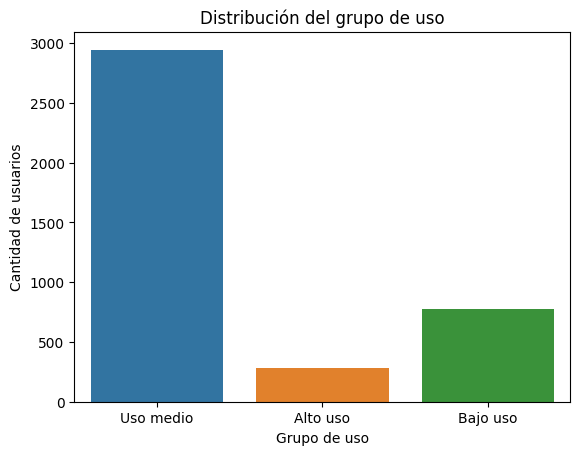

In [62]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Distribución del grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()


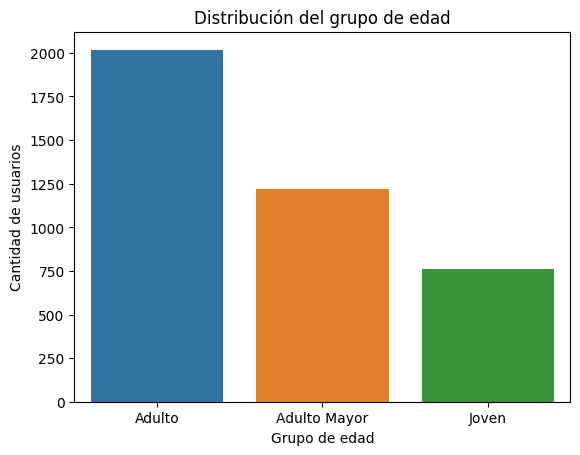

In [63]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución del grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmente los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

Los datos originales presentaban problemas de calidad que debían corregirse antes del análisis, principalmente relacionados con valores ausentes o inconsistentes. La limpieza de estos datos fue necesaria para evitar que afectaran la segmentación y las conclusiones obtenidas. El porcentaje exacto de filas afectadas depende del resultado de la revisión de valores faltantes realizada previamente.

En cuanto a la edad, se identificaron tres segmentos. El grupo más grande es el de Adultos, con aproximadamente 2.020 usuarios (50,5%). Le siguen los Adultos Mayores, con cerca de 1.220 usuarios (30,5%), mientras que los Jóvenes representan aproximadamente 760 usuarios (19%). Esto indica que ConnectaTel tiene una base de clientes principalmente adulta, por lo que este segmento debería ser especialmente importante en la estrategia comercial.

Respecto al nivel de uso, la mayoría de los clientes pertenece al grupo de Uso medio, con aproximadamente 2.940 usuarios (73,5%). Los clientes de Bajo uso representan cerca de 780 usuarios (19,5%), mientras que solamente unos 280 usuarios (7%) pertenecen al segmento de Alto uso. Por lo tanto, la mayor parte de los clientes tiene un consumo moderado de los servicios.

Los segmentos que parecen más valiosos para ConnectaTel son los clientes de alto uso, aunque representan una proporción pequeña de la cartera. Estos usuarios tienen un mayor nivel de consumo y podrían generar mayores ingresos, por lo que sería conveniente ofrecerles planes premium, mayores beneficios y estrategias de fidelización. También es importante prestar atención a los adultos, ya que constituyen aproximadamente la mitad de la base de clientes.

Los patrones de uso extremo (outliers) pueden representar clientes con un consumo excepcionalmente alto de llamadas, mensajes o minutos. Estos usuarios podrían tener necesidades diferentes a las del cliente promedio y, por ello, representan una oportunidad para diseñar planes específicos. Sin embargo, antes de tomar decisiones comerciales, es importante comprobar que estos valores extremos sean reales y no errores de registro.

Con base en los segmentos encontrados, recomendaría mantener una estrategia de planes diferenciados. Para los clientes de bajo uso, ConnectaTel podría ofrecer planes económicos con menores cantidades de llamadas y mensajes. Para el gran grupo de uso medio, sería conveniente mantener planes equilibrados que cubran las necesidades habituales. Para los clientes de alto uso, se podrían crear planes premium con mayores límites, beneficios adicionales y descuentos por fidelización.

Finalmente, sería interesante analizar la combinación de edad + nivel de uso. Por ejemplo, identificar cuántos adultos, jóvenes y adultos mayores pertenecen al segmento de alto uso permitiría crear ofertas todavía más personalizadas. Esto ayudaría a ConnectaTel no solo a aumentar los ingresos, sino también a reducir la posibilidad de que los clientes de mayor valor migren hacia otras compañías.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`